# 02 · Standard FunnyBird CBM: controlled discovery of concept backwash

**Report question.** When one FunnyBird part is replaced while body, pose,
camera, and background stay fixed, does the corresponding concept answer
follow the inserted part or remain attached to the old bird?

**Population.** Standard non-RL CBM. This notebook contains no MCBM and no
visibility-aware relabelled model. Seed-level replication is shown where
accepted outputs exist; the fixed-render causal analysis begins with seed 1.

**Claims available here.** FunnyBird's renderer permits a controlled
donor-part replacement. Therefore a validated positive donor response plus
a remaining source preference can establish the CBM backwash event. Proposed
explanations are weaker unless independently manipulated.


## What this notebook must prove, and how the figures build the claim

The final claim is deliberately narrower than “the model is inaccurate.” A
FunnyBird **backwash event** requires both of the following on the *same
controlled replacement*:

1. the donor part moves the raw concept comparison toward the donor
   (`response_delta > 0`); and
2. after that movement, the old source concept is still higher
   (`m_cf < 0`).

Example: replacing a red tail with a blue tail raises the blue-tail score
relative to red by 24 units, but red still finishes 6 units above blue. The
model reacted to the new tail pixels, yet its final concept answer remained
attached to the old bird. That is the event tested in Figure 4.

Before accepting it, the report must establish these components in order:

| Step | Needed fact | Figure(s) | Why it is needed |
|---|---|---|---|
| 1 | the trained concept outputs are usable | 1 | a constant or broken output cannot support grounding analysis |
| 2 | the renderer really changed only the named part | 2 | otherwise a score change cannot be assigned to that part |
| 3 | the inserted pixels cause donorward movement | 3 | proves the model saw some evidence in the new part |
| 4 | the old source can still win after that movement | 4 | this is the controlled backwash predicate |
| 5 | the event is not a direction-averaging artifact | 5 | checks forward and reverse replacements separately |
| 6 | test proposed contributors | 6–8 | visibility/occlusion, conflicting labels, exact-value difficulty, support/alternatives, and source species |
| 7 | measure what those contributors predict and what remains | 9 | prevents claiming that a plausible story explains all rows |
| 8 | measure downstream class impact | 10 | separates explanation failure from species-classification harm |

### Capabilities and limits that determine this design

FunnyBird supplies an exact renderer mask and a clean donor-part replacement:
body, pose, camera, and background can remain unchanged while one part changes.
That makes Figures 3–4 causal tests of the changed part pixels. Visibility,
training-label conflict, exact value, support, and species are then investigated
as possible contributors. Except for the later matched RLv2 retraining, those
contributor analyses are observational and are not allowed to erase the
controlled event or claim that every cause has been found.

### Predictions stated before the results

- If the concept is locally grounded, replacement should produce
  `response_delta > 0` and usually `m_cf > 0`.
- If backwash occurs, a nontrivial set should have `response_delta > 0` but
  `m_cf < 0`.
- If visibility/occlusion is sufficient, the event should disappear for large,
  clearly visible inserted parts.
- If label–visibility conflict contributes, parts with more positive labels on
  invisible parts should later improve most under matched RLv2 training.
- If exact-value difficulty or species context contributes, matched rows should
  retain systematic value- or species-linked differences.
- None of these predictions requires the measured contributors to reduce the
  remaining error to zero.


## The implemented CBM and the notation used below

For image `i`, the encoder produces one latent value for every concept slot.
The learned concept head then turns that latent value into a raw concept logit:

```text
x_i → image encoder → h_i = (h_i1, …, h_iJ)
                          ├→ learned head q_j(h_ij) → z_ij → sigmoid → p_ij
                          └→ class head on complete h_i       → species prediction
```

The implementation trains with

`L_CBM = L_task + beta × L_concept`.

The class head reads the complete latent vector `h_i`; it does not read a list of
hard 0/1 concept decisions. In these runs each concept head is a learned
`1 → 3 → 1` network, not the identity. The setup cell replays the saved head
weights on saved `h_i` and verifies that `sigmoid(z_ij)` exactly reproduces
the saved probability.

| Symbol | Meaning |
|---|---|
| `x_i` | image `i` |
| `y_i` | species label |
| `c_ij` | processed 0/1 label for exact concept `j` |
| `h_ij` | encoder's latent slot for concept `j`; also read by the class head |
| `z_ij = q_j(h_ij)` | raw concept logit after the learned head; primary grounding quantity |
| `p_ij = sigmoid(z_ij)` | bounded probability; used only for thresholded performance |
| `c_hat_ij = 1[z_ij>0]` | predicted concept presence |
| `v_ig` | whether mapped part mask `g` is visible |
| `a_ig` | visible area of mask `g` |

Ordinary accuracy and recall answer whether predictions agree with labels. They
do **not** answer whether the prediction came from the named pixels.


In [1]:
import os, json, re, glob, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image as DisplayImage

CURATED = Path(os.environ["CURATED_DATA"])
CWD = Path.cwd()
REPO = CWD if (CWD/"analysis").is_dir() else CWD.parent
sys.path.insert(0, str(REPO/"data"/"funnybirds"))
plt.rcParams.update({"figure.dpi": 120, "axes.grid": False})
ORDER = ["tail", "wing", "beak", "foot", "eye"]
COLORS = {"tail":"#6A0DAD", "wing":"#0072B2", "beak":"#E69F00",
          "foot":"#009E73", "eye":"#CC79A7"}

def require(path, command):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}\nProduce it with: {command}")
    return path

swap_candidates = [
    CURATED/"swap_fixed_v3_matched"/"funnybirds-cbm-s1.csv",
    CURATED/"swap_fixed_v2_attempt2"/"funnybirds-cbm-s1.csv",
    CURATED/"swap_fixed_v2"/"funnybirds-cbm-s1.csv",
]
SWAP = next((p for p in swap_candidates if p.exists()), None)
if SWAP is None:
    raise FileNotFoundError("No accepted fixed-render standard-CBM swap CSV")
S = pd.read_csv(SWAP)
# Legacy column names start with z_, but the renderer driver stored
# model output["c_logits"] after the learned concept head.  In report
# notation these are z_source and z_donor, not latent h values.
if "response_delta" not in S:
    S["response_delta"] = S.margin - (S.z_new_orig - S.z_old_orig)
S["responded_but_source_wins"] = (S.response_delta > 0) & (S.margin < 0)
print("fixed-render input:", SWAP)
print("rows:", len(S), "parts:", sorted(S.part.unique()))

PRED_DIR = REPO/"external"/"minimal_cbm"/"results"/"funnybirds-cbm"/"1"/"predictions"
PRED = require(PRED_DIR/"epoch_100.pth", "train or restore funnybirds-cbm seed 1 epoch 100")
import torch
saved = torch.load(PRED, map_location="cpu", weights_only=False)
latent_h_saved = saved["z"].detach().cpu().numpy().reshape(len(saved["z"]), -1)
p_saved = saved["c_preds"].detach().cpu().numpy().reshape(len(saved["c_preds"]), -1)
c_saved = saved["c"].detach().cpu().numpy().reshape(len(saved["c"]), -1)
MODEL = require(REPO/"external"/"minimal_cbm"/"results"/"funnybirds-cbm"/"1"/"models"/"epoch_100.pt",
                "train or restore funnybirds-cbm seed 1 epoch 100")
sys.path.insert(0, str(REPO/"analysis"))
from minimal_cbm_scores import concept_logits_from_saved_latent, validate_saved_probabilities
logit_tensor = concept_logits_from_saved_latent(saved["z"], MODEL, c_saved.shape[1])
head_error = validate_saved_probabilities(logit_tensor, saved["c_preds"])
z_saved = logit_tensor.numpy()
print(f"[CONCEPT-HEAD REPLAY PASS] max |sigmoid(raw_logit)-saved_prob|={head_error:.3g}")

FB_ROOT = Path(os.environ.get("FUNNYBIRDS_ROOT", CURATED/"FunnyBirds"))
import funnybirds_concepts as fbc
parts = fbc.load_parts(FB_ROOT)
CONCEPT_NAMES = fbc.concept_names(parts)
SPANS = fbc.group_slices(parts)
if len(CONCEPT_NAMES) != z_saved.shape[1]:
    raise RuntimeError("parts.json concept width does not match saved predictions")
CONCEPT_PART = {name: part for part,(a,b) in SPANS.items() for name in CONCEPT_NAMES[a:b]}
print("checkpoint:", PRED, "concepts:", len(CONCEPT_NAMES), "species:", len(np.unique(saved["y"])))


fixed-render input: /scratch/network/cr7998/cv_emergence_project/curated_data/swap_fixed_v3_matched/funnybirds-cbm-s1.csv
rows: 5000 parts: ['beak', 'eye', 'foot', 'tail', 'wing']


[CONCEPT-HEAD REPLAY PASS] max |sigmoid(raw_logit)-saved_prob|=2.38e-07
checkpoint: /scratch/network/cr7998/cv_emergence_project/curated/external/minimal_cbm/results/funnybirds-cbm/1/predictions/epoch_100.pth concepts: 26 species: 50


## 1 · Did training produce a usable, non-collapsed CBM?

**Question.** Did training produce a usable, non-collapsed CBM?

**Variables and prediction.** For every exact concept `j`, measure raw-score spread, positive-versus-negative label separation, balanced accuracy, and positive recall. A usable slot has nonzero spread, positive label separation, and above-chance thresholded performance.

**Method.** Compute all quantities from the epoch-100 held-out predictions. Recall is a health statistic, not grounding evidence.

### Figure 1 · Did training produce a usable, non-collapsed CBM?

**How to read the figure.** Each row is one exact concept, such as `yellow tail`. The four panels use the
same rows. `spread = Q95(z)-Q05(z)` asks whether the output changes across
test images; exactly zero means a constant output. `label separation =
median(z|c=1)-median(z|c=0)` asks how far positive-labelled images sit above
negative-labelled images; positive is the expected direction. `balanced
accuracy = (positive recall + negative recall)/2` gives positive and negative
labels equal weight; 0.5 is chance for a binary concept. `positive recall =
P(z>0|c=1)` is the fraction of labelled-positive images called positive.
Example: positive recall 0.90 means 90 of 100 positive-labelled images have
`z>0`. These are health checks, not evidence about which pixels produced `z`.


,images,species,task_accuracy,concept_accuracy
0,5000,50,0.7504,0.9944


,concept,part,spread,label_separation,balanced_accuracy,positive_recall,n_positive,n_negative
0,beak_0,beak,41.720,29.145000,0.995,0.995,1598,3402
1,beak_1,beak,36.964,27.024000,0.995,0.992,736,4264
2,beak_2,beak,22.300,23.559999,0.994,0.988,432,4568
3,beak_3,beak,28.012,24.921000,0.998,0.999,998,4002
4,eye_0,eye,42.064,29.084999,0.997,0.999,1133,3867
5,eye_1,eye,31.876,22.716999,0.996,0.993,1204,3796
6,eye_2,eye,41.357,28.090000,0.995,0.994,1432,3568
7,foot_0,foot,40.429,29.865999,1.000,1.000,972,4028
8,foot_1,foot,31.737,29.349001,0.998,0.997,762,4238
9,foot_2,foot,46.488,33.603001,0.998,0.998,1051,3949


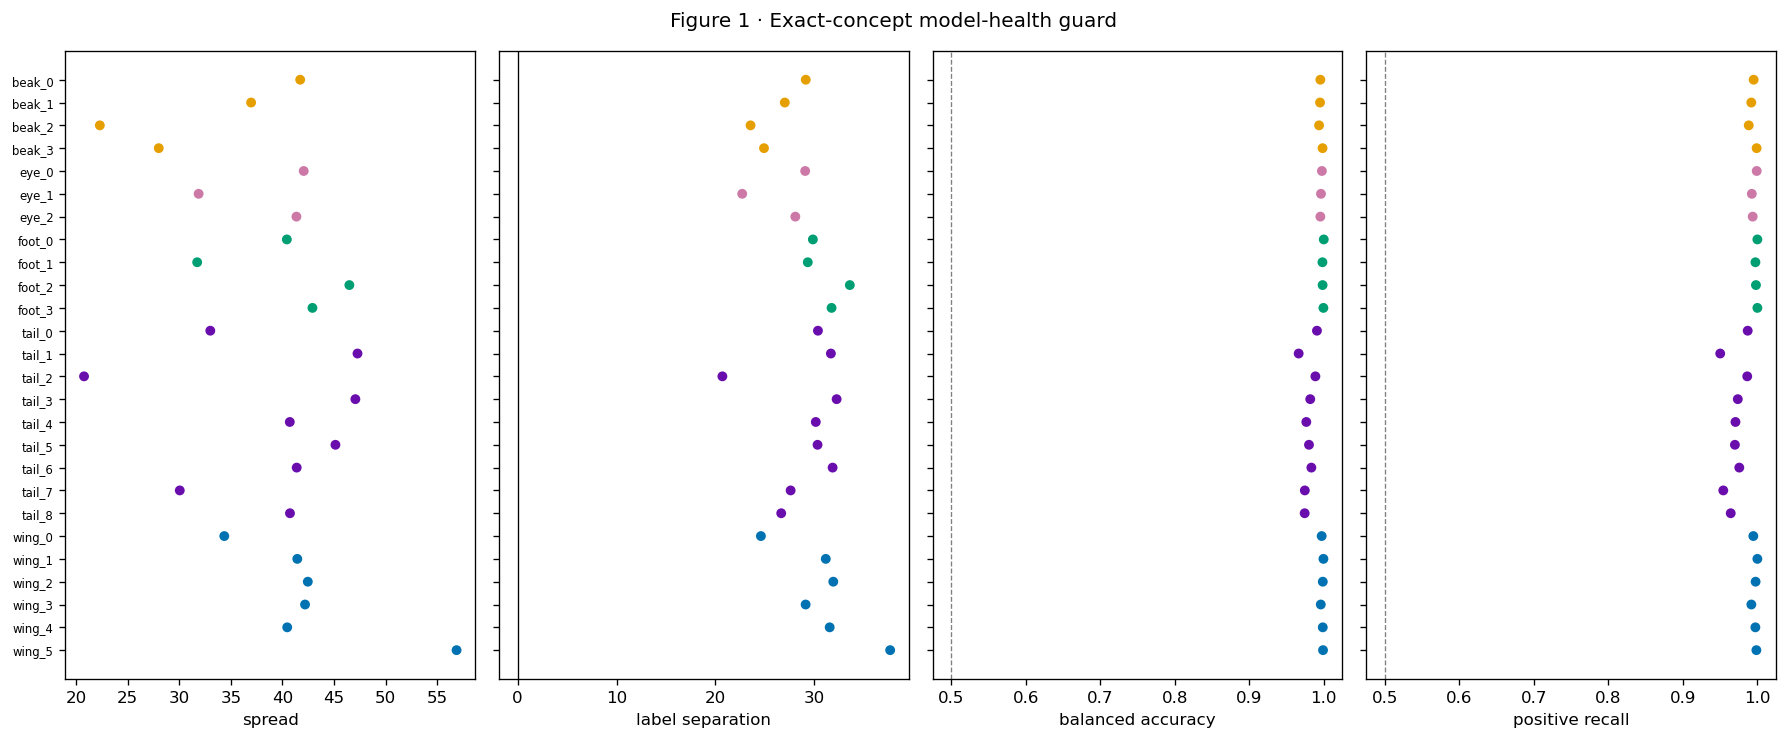

In [2]:
# ALT: Four aligned dot plots showing raw-score spread, label separation, balanced accuracy, and positive recall for every FunnyBird concept.
def balanced_accuracy(y, pred):
    y=np.asarray(y).astype(int); pred=np.asarray(pred).astype(int)
    tpr=(pred[y==1]==1).mean() if (y==1).any() else np.nan
    tnr=(pred[y==0]==0).mean() if (y==0).any() else np.nan
    return np.nanmean([tpr,tnr])

rows=[]
for j,name in enumerate(CONCEPT_NAMES):
    z=z_saved[:,j]; c=c_saved[:,j].astype(int); pred=(z>0).astype(int)
    rows.append({"concept":name,"part":CONCEPT_PART[name],
                 "spread":np.quantile(z,.95)-np.quantile(z,.05),
                 "label_separation":np.median(z[c==1])-np.median(z[c==0]),
                 "balanced_accuracy":balanced_accuracy(c,pred),
                 "positive_recall":pred[c==1].mean(),
                 "n_positive":int(c.sum()),"n_negative":int((c==0).sum())})
HEALTH=pd.DataFrame(rows).sort_values(["part","concept"])
y_true=np.asarray(saved["y"]).reshape(-1).astype(int)
y_scores=np.asarray(saved["y_preds"])
if y_scores.ndim>2: y_scores=y_scores.reshape(len(y_scores),-1)
task_accuracy=float((y_scores.argmax(1)==y_true).mean())
concept_accuracy=float(((z_saved>0)==c_saved).mean())
display(pd.DataFrame([{"images":len(y_true),"species":len(np.unique(y_true)),
                      "task_accuracy":task_accuracy,"concept_accuracy":concept_accuracy}]).round(4))
display(HEALTH.round(3))
metrics=["spread","label_separation","balanced_accuracy","positive_recall"]
fig,axes=plt.subplots(1,4,figsize=(15,max(5,.24*len(HEALTH))),sharey=True)
y=np.arange(len(HEALTH))
for ax,m in zip(axes,metrics):
    ax.scatter(HEALTH[m],y,c=HEALTH.part.map(COLORS).fillna("#BBBBBB"),s=24)
    ax.set_xlabel(m.replace("_"," "))
    if m in ["label_separation"]: ax.axvline(0,color="black",lw=.8)
    if m in ["balanced_accuracy","positive_recall"]: ax.axvline(.5,color="gray",ls="--",lw=.8)
axes[0].set_yticks(y); axes[0].set_yticklabels(HEALTH.concept,fontsize=7)
axes[0].invert_yaxis(); fig.suptitle("Figure 1 · Exact-concept model-health guard")
plt.tight_layout(); plt.show()


### Review record for Figure 1

- **Literal observation:** All 26 exact outputs vary substantially: raw-z spread is 20.77-56.88, label separation is 20.71-37.68, balanced accuracy is 0.966-1.000, and positive recall is 0.950-1.000. Image classification accuracy is 0.7504 and concept accuracy is 0.9944.
- **Strongest alternative explanation:** Excellent label prediction can still come from species context rather than the named part, so this figure establishes health but not grounding.
- **Discriminating test:** Use the same-image controlled replacement in Figures 3-4.
- **Limited conclusion:** `ACCEPTED FOR seed-1 standard-CBM model health; no exact output is collapsed.`
- **Next question:** Is the fixed renderer intervention itself valid?


## 2 · Did the renderer change only the intended part?

**Question.** Did the renderer change only the intended part?

**Variables and prediction.** Inspect the semantic preflight and original/swap/delete/part-map examples for all five parts. A valid intervention visibly changes the target part, preserves the rest of the scene, and has nonzero target-mask pixels.

**Method.** Use artifacts from the accepted fixed-render root before reading any model response.

### Figure 2 · Did the renderer change only the intended part?

**How to read the figure.** Rows are the five FunnyBird parts. Columns show the original bird, the donor
replacement, deletion, and the replacement's part mask. The test is visual:
the named part should change while body, pose, camera, and background remain
fixed. This validates the intervention before model scores are interpreted.


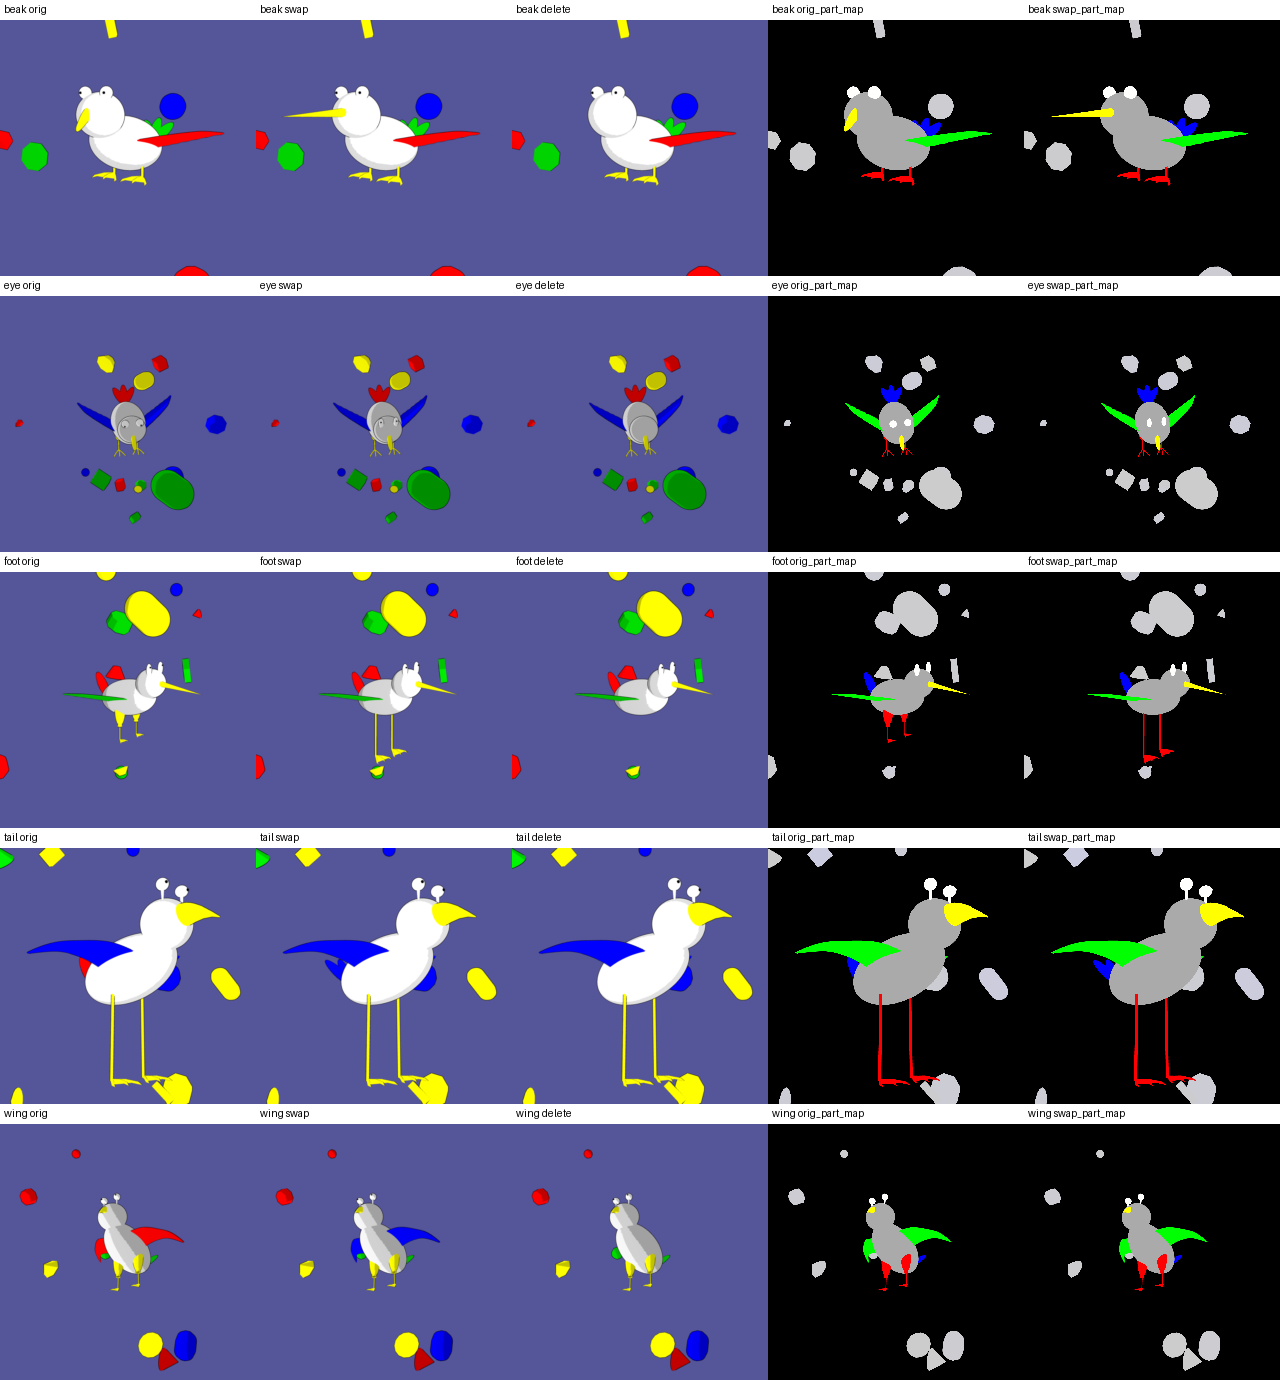

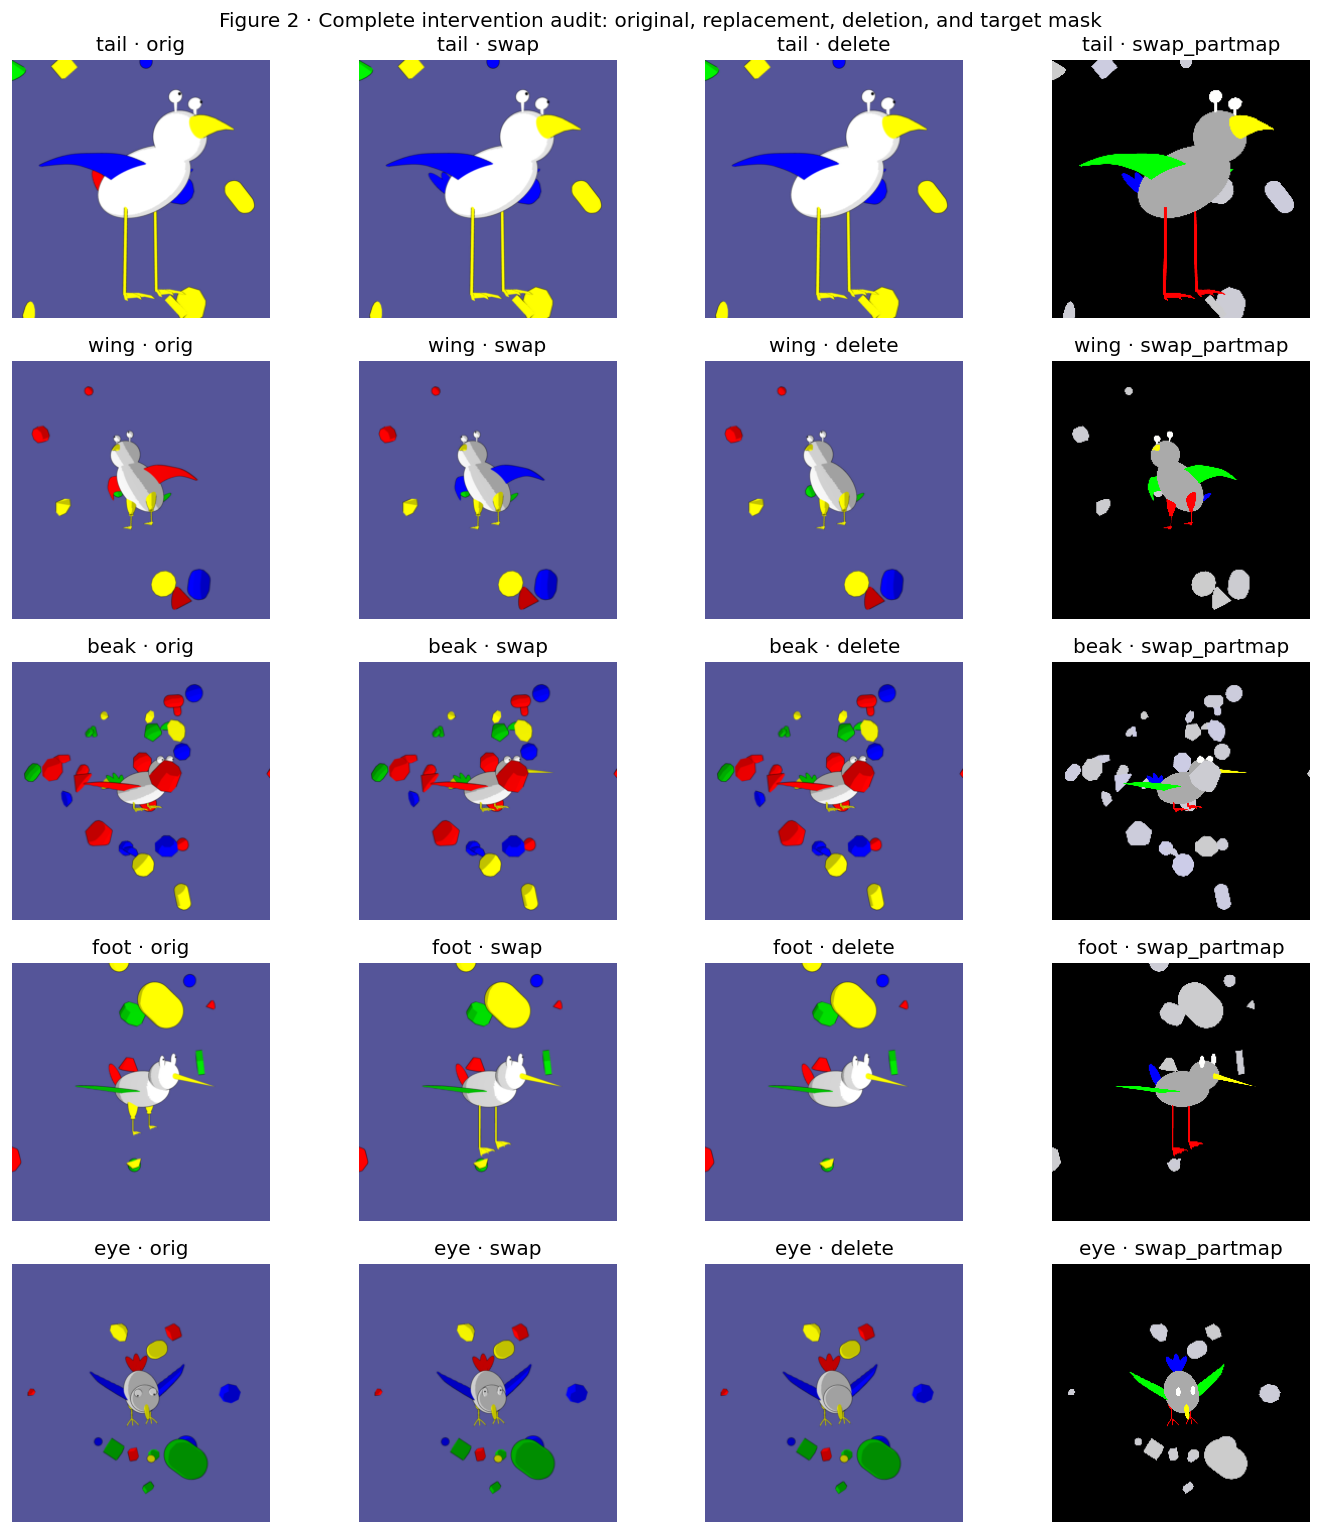

In [3]:
# ALT: Complete FunnyBird intervention audit showing original, swapped, deleted, and part-map images for tail, wing, beak, foot, and eye.
ROOT = SWAP.parent
preflight_candidates=[ROOT/"renderer_preflight"/"renderer_semantic_preflight.png",
                      CURATED/"swap_fixed_v2_attempt2"/"renderer_preflight"/"renderer_semantic_preflight.png"]
preflight=next((p for p in preflight_candidates if p.exists()),preflight_candidates[0])
example_candidates=[ROOT/"examples",CURATED/"swap_fixed_v2_attempt2"/"examples"]
examples=next((p for p in example_candidates if p.is_dir()),example_candidates[0])
if preflight.exists():
    display(DisplayImage(filename=str(preflight)))
else:
    print("preflight sheet not stored beside CSV; use accepted job-3330289 audit")
from PIL import Image
tags=["orig","swap","delete","swap_partmap"]
fig,axes=plt.subplots(len(ORDER),len(tags),figsize=(12,13))
for r,part in enumerate(ORDER):
    for c,tag in enumerate(tags):
        ax=axes[r,c]; files=sorted(examples.glob(f"{part}_*_{tag}.png"))
        if files: ax.imshow(Image.open(files[0]).convert("RGB"))
        else: ax.text(.5,.5,"missing",ha="center",va="center")
        ax.set_title(f"{part} · {tag}"); ax.axis("off")
fig.suptitle("Figure 2 · Complete intervention audit: original, replacement, deletion, and target mask")
plt.tight_layout(); plt.show()


### Review record for Figure 2

- **Literal observation:** For tail, wing, beak, foot, and eye, the displayed replacement and deletion alter the named part while the body, pose, camera, and background remain fixed; the target part map contains the changed region.
- **Strongest alternative explanation:** A few photographs alone would not certify the full cache.
- **Discriminating test:** Retain the semantic preflight plus the accepted fixed-render hash/diversity validation across all evaluated models and render IDs.
- **Limited conclusion:** `ACCEPTED FOR the validated FunnyBird fixed-render intervention.`
- **Next question:** Do those inserted pixels move the raw concept comparison toward the donor?


## 3 · Did the inserted pixels move the comparison toward the donor?

**Question.** Did the inserted pixels move the comparison toward the donor?

**Variables and prediction.** `response_delta = (z_donor-z_source)_cf - (z_donor-z_source)_orig`. Legacy CSV columns named `z_*` contain these post-head raw logits. Values above zero mean that replacement pixels moved the model toward the donor concept.

**Method.** Plot the complete distribution for every part and report the positive-response rate.

### Figure 3 · Did the inserted pixels move the comparison toward the donor?

**How to read the figure.** The x-axis is `response_delta` in raw-logit units and each distribution is one
part. Zero means the swap caused no donorward change; values to the right of
zero mean the donor gained relative to the old source. This figure measures
response size, not whether the donor ultimately wins.


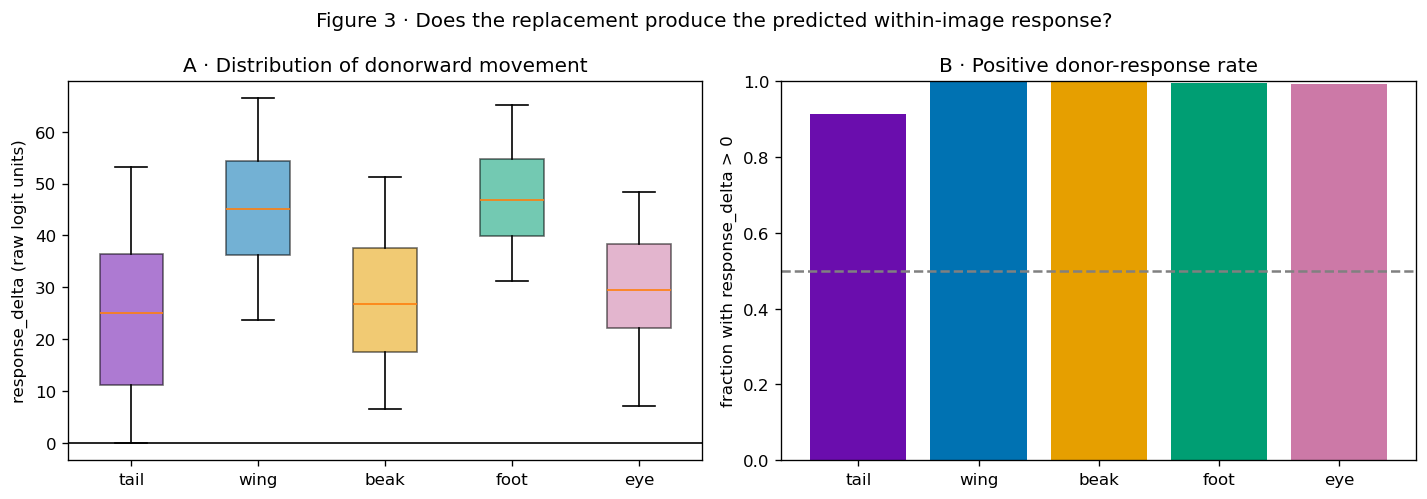

,positive_response_rate
part,
tail,0.913
wing,0.999
beak,0.997
foot,0.995
eye,0.993


In [4]:
# ALT: FunnyBird response-delta distributions and positive donor-response rates for all five parts.
fig,axes=plt.subplots(1,2,figsize=(12,4.2))
vals=[S.loc[S.part==p,"response_delta"].dropna() for p in ORDER]
bp=axes[0].boxplot(vals,tick_labels=ORDER,showfliers=False,whis=(5,95),patch_artist=True)
for box,p in zip(bp["boxes"],ORDER): box.set_facecolor(COLORS[p]); box.set_alpha(.55)
axes[0].axhline(0,color="black",lw=1); axes[0].set_ylabel("response_delta (raw logit units)")
axes[0].set_title("A · Distribution of donorward movement")
rate=S.groupby("part").response_delta.apply(lambda x:(x>0).mean()).reindex(ORDER)
axes[1].bar(rate.index,rate.values,color=[COLORS[p] for p in rate.index])
axes[1].axhline(.5,color="gray",ls="--"); axes[1].set_ylim(0,1)
axes[1].set_ylabel("fraction with response_delta > 0"); axes[1].set_title("B · Positive donor-response rate")
fig.suptitle("Figure 3 · Does the replacement produce the predicted within-image response?")
plt.tight_layout(); plt.show(); display(rate.rename("positive_response_rate").to_frame().round(3))


### Review record for Figure 3

- **Literal observation:** Median donorward movement is positive for every part, and the positive-response rates are tail 0.913, wing 0.999, beak 0.997, foot 0.995, and eye 0.993.
- **Strongest alternative explanation:** A positive movement alone does not say that the inserted donor finishes above the old source.
- **Discriminating test:** Inspect the final donor-minus-source margin jointly with response_delta.
- **Limited conclusion:** `ACCEPTED FOR a causal within-image response to the inserted part pixels.`
- **Next question:** After that response, which concept finishes stronger?


## 4 · After responding, does the donor finish above the old source?

**Question.** After responding, does the donor finish above the old source?

**Variables and prediction.** The final margin is `m_cf=z_donor,cf-z_source,cf`. The primary event is `response_delta>0` with `m_cf<0`. A lower-right quadrant point means the inserted pixels had an effect but the old source still wins.

**Method.** Show final-margin distributions and the joint response/margin plane for every part.

### Figure 4 · After responding, does the donor finish above the old source?

**How to read the figure.** In the margin panel, zero separates donor wins (`m_cf>0`) from old-source wins
(`m_cf<0`). In the quadrant panel, x is donorward movement and y is the final
donor-minus-source score. The lower-right quadrant is the exact candidate
event: the new pixels moved the answer toward the donor, but the old source
still finished higher.


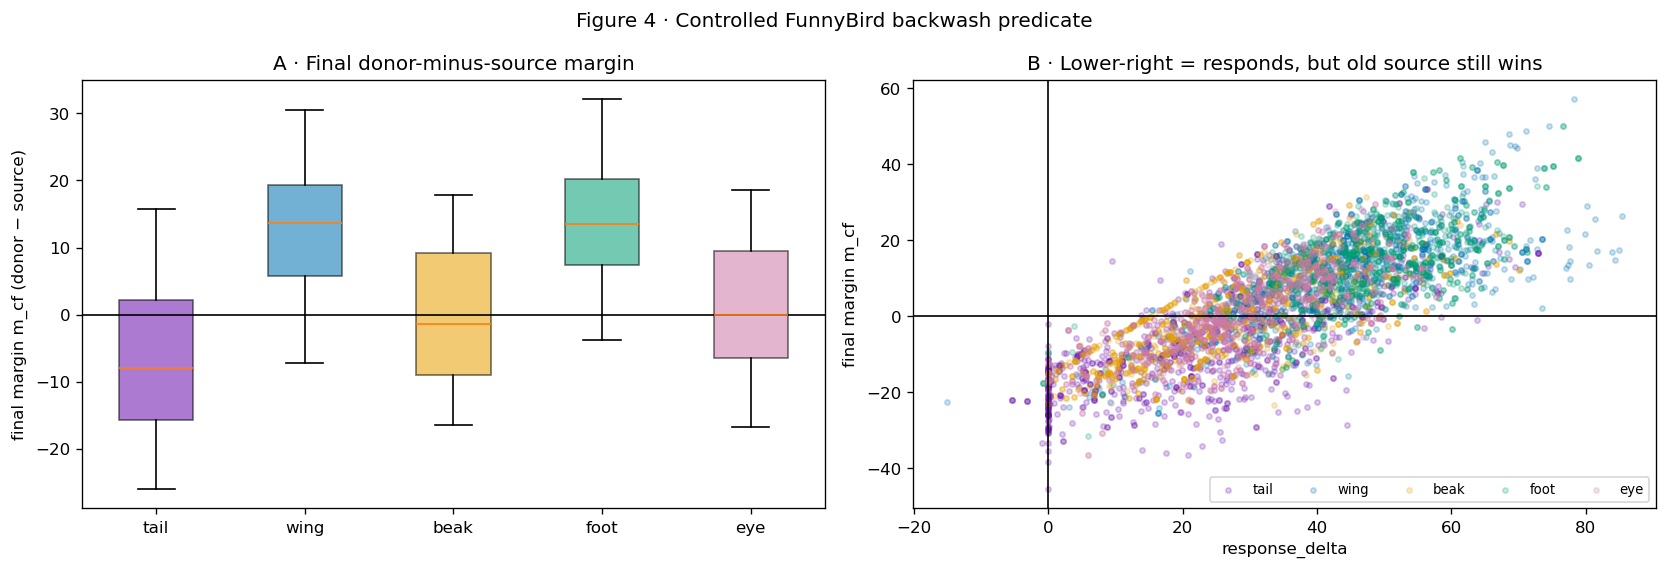

,n,median_response,median_final_margin,positive_response_rate,responded_but_source_wins_rate
part,,,,,
tail,1000,25.029,-7.927,0.913,0.608
wing,1000,45.084,13.665,0.999,0.133
beak,1000,26.834,-1.368,0.997,0.537
foot,1000,46.776,13.559,0.995,0.084
eye,1000,29.424,0.011,0.993,0.491


In [5]:
# ALT: Final donor-minus-source margin distributions and joint response-delta versus final-margin plot for all FunnyBird parts.
fig,axes=plt.subplots(1,2,figsize=(14,4.8))
vals=[S.loc[S.part==p,"margin"].dropna() for p in ORDER]
bp=axes[0].boxplot(vals,tick_labels=ORDER,showfliers=False,whis=(5,95),patch_artist=True)
for box,p in zip(bp["boxes"],ORDER): box.set_facecolor(COLORS[p]); box.set_alpha(.55)
axes[0].axhline(0,color="black",lw=1); axes[0].set_ylabel("final margin m_cf (donor − source)")
axes[0].set_title("A · Final donor-minus-source margin")
for p in ORDER:
    d=S[S.part==p]
    axes[1].scatter(d.response_delta,d.margin,s=10,alpha=.22,color=COLORS[p],label=p)
axes[1].axvline(0,color="black",lw=1); axes[1].axhline(0,color="black",lw=1)
axes[1].set_xlabel("response_delta"); axes[1].set_ylabel("final margin m_cf")
axes[1].set_title("B · Lower-right = responds, but old source still wins")
axes[1].legend(ncol=5,fontsize=8)
fig.suptitle("Figure 4 · Controlled FunnyBird backwash predicate")
plt.tight_layout(); plt.show()
summary=S.groupby("part").agg(n=("margin","size"),median_response=("response_delta","median"),
    median_final_margin=("margin","median"),positive_response_rate=("response_delta",lambda x:(x>0).mean()),
    responded_but_source_wins_rate=("responded_but_source_wins","mean")).reindex(ORDER)
display(summary.round(3))


### Review record for Figure 4

- **Literal observation:** The median final margin is negative for tail (-7.927) and beak (-1.368), near zero for eye (0.011), and positive for wing (13.665) and foot (13.559). The responded-but-source-wins rates are 0.608, 0.537, 0.491, 0.133, and 0.084, respectively.
- **Strongest alternative explanation:** Starting preference, swap direction, target visibility, exact value difficulty, and source species could organize the unequal rates.
- **Discriminating test:** Test those alternatives separately in Figures 5-9 without changing the event definition.
- **Limited conclusion:** `ACCEPTED FOR the seed-1 controlled FunnyBird backwash predicate, strongest for tail, beak, and eye; wing and foot also contain minority events.`
- **Next question:** Can swap direction create the pooled pattern?


## 5 · Could opposite swap directions create the result?

**Question.** Could opposite swap directions create the result?

**Variables and prediction.** Compare forward and backward rates of `response_delta>0 and final margin<0`, together with median margins. A genuine part pattern should appear in both directions rather than cancel when pooled.

**Method.** Keep directions separate and show their denominators.

### Figure 5 · Could opposite swap directions create the result?

**How to read the figure.** Each part has separate forward and reverse replacement estimates. The rate is
the fraction of rows in the lower-right quadrant from Figure 4; the printed
denominator is the number of swaps. Similar values in both directions argue
against a pooled average hiding opposite effects.


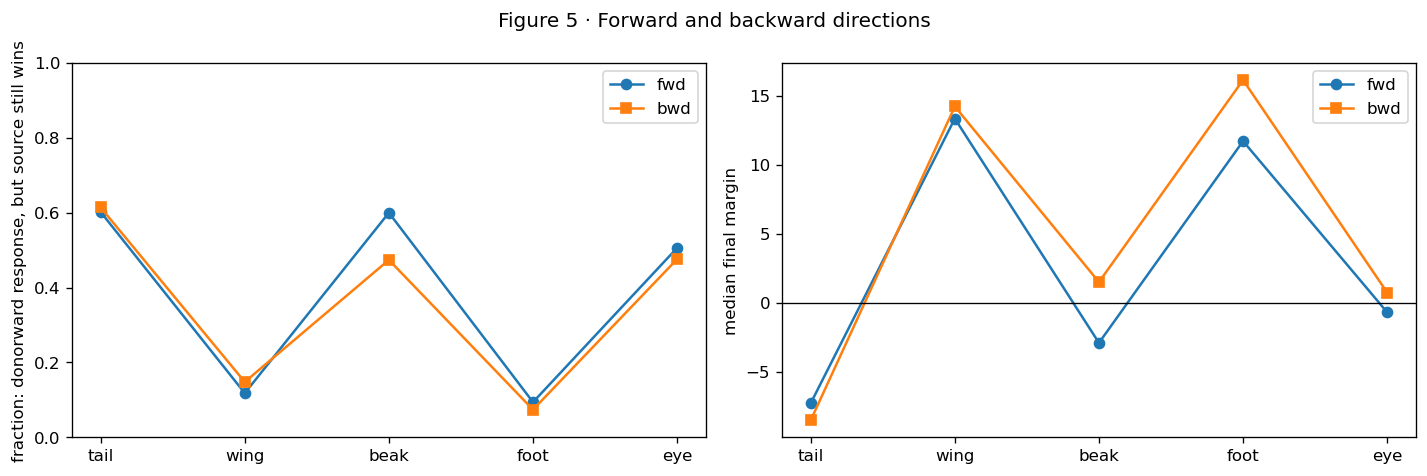

,part,direction,n,median_margin,responded_but_source_wins_rate
0,beak,bwd,500,1.516,0.474
1,beak,fwd,500,-2.886,0.600
2,eye,bwd,500,0.757,0.476
3,eye,fwd,500,-0.675,0.506
4,foot,bwd,500,16.138,0.074
5,foot,fwd,500,11.715,0.094
6,tail,bwd,500,-8.492,0.614
7,tail,fwd,500,-7.255,0.602
8,wing,bwd,500,14.222,0.148
9,wing,fwd,500,13.345,0.118


In [6]:
# ALT: Forward and backward FunnyBird rates where the donor changes the margin but the old source remains larger, alongside final margins for every part.
D=(S.groupby(["part","direction"]).agg(n=("margin","size"),median_margin=("margin","median"),
     responded_but_source_wins_rate=("responded_but_source_wins","mean")).reset_index())
fig,axes=plt.subplots(1,2,figsize=(12,4))
for direction,marker in [("fwd","o"),("bwd","s")]:
    d=D[D.direction==direction].set_index("part").reindex(ORDER)
    axes[0].plot(ORDER,d.responded_but_source_wins_rate,marker=marker,label=direction)
    axes[1].plot(ORDER,d.median_margin,marker=marker,label=direction)
axes[0].set_ylim(0,1); axes[0].set_ylabel("fraction: donorward response, but source still wins")
axes[1].axhline(0,color="black",lw=.8); axes[1].set_ylabel("median final margin")
axes[0].legend(); axes[1].legend(); fig.suptitle("Figure 5 · Forward and backward directions")
plt.tight_layout(); plt.show(); display(D.round(3))


### Review record for Figure 5

- **Literal observation:** Forward and backward results have the same part ordering. Tail remains near 0.60 in both directions, while wing and foot remain near 0.07-0.15; beak and eye remain intermediate.
- **Strongest alternative explanation:** Individual source/donor value pairs can still be asymmetric even when pooled directions agree.
- **Discriminating test:** Inspect every exact inserted value and both direction-specific denominators.
- **Limited conclusion:** `ACCEPTED FOR excluding opposite-direction cancellation as the main explanation.`
- **Next question:** How does exact target visibility change the event?


## 6 · How much of the result is associated with target visibility?

**Question.** How much of the result is associated with target visibility?

**Variables and prediction.** Use `pixel_count_cf` from the exact swapped-part map and the same final-margin and `response_delta>0, margin<0` definition. If visibility is sufficient, highly visible replacements should remove the part gap; a remaining gap requires another explanation.

**Method.** Use declared bins and print the number of swap rows in every bin.

### Figure 6 · How much of the result is associated with target visibility?

**How to read the figure.** The x-axis bins swaps by the number of visible pixels in the inserted target
part. One panel shows median final raw-logit margin; the other shows the
responded-but-source-wins fraction. If visibility were the whole explanation,
sufficiently large visible parts should make margins positive and drive that
fraction near zero for every part.


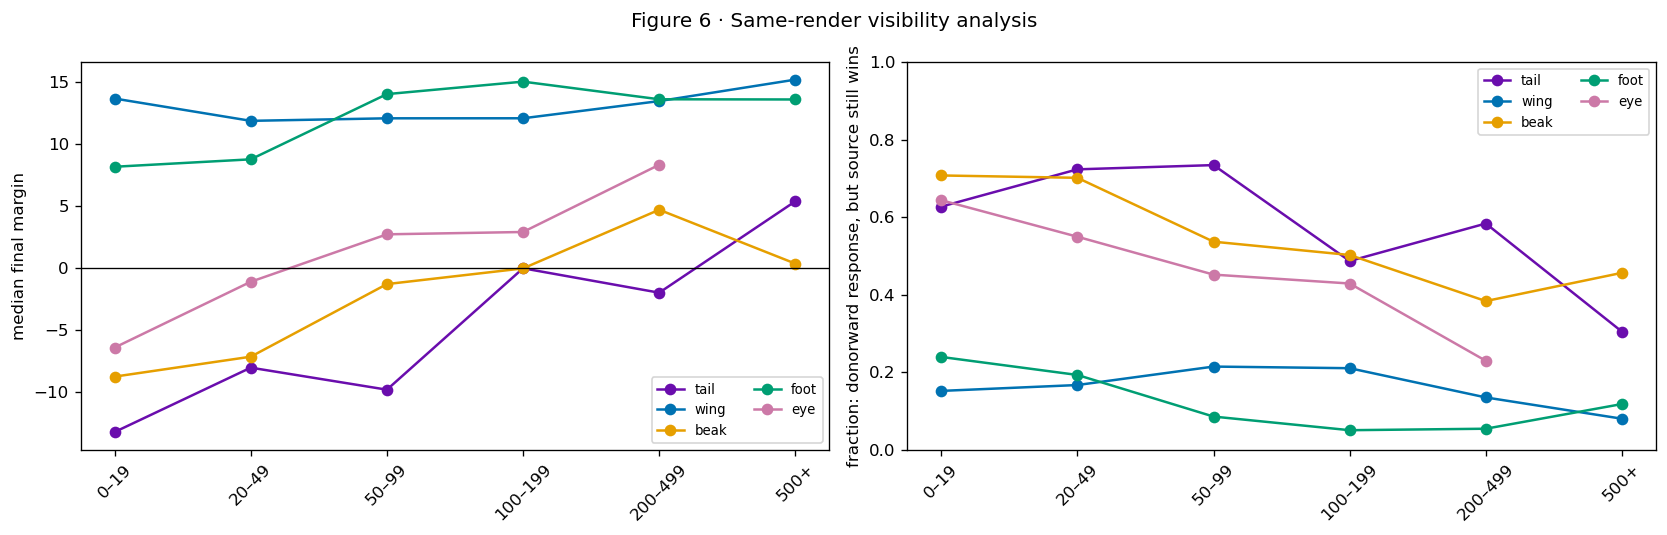

,part,visibility_bin,n,median_margin,responded_but_source_wins_rate
0,beak,0–19,123,-8.758,0.707
1,beak,20–49,164,-7.153,0.701
2,beak,50–99,192,-1.307,0.536
3,beak,100–199,237,-0.043,0.502
4,beak,200–499,227,4.679,0.383
5,beak,500+,57,0.342,0.456
6,eye,0–19,115,-6.418,0.643
7,eye,20–49,335,-1.119,0.549
8,eye,50–99,299,2.701,0.452
9,eye,100–199,203,2.888,0.429


In [7]:
# ALT: FunnyBird final margin and responded-but-source-still-wins rate across exact swapped-part visibility bins for all parts.
if "pixel_count_cf" not in S: raise RuntimeError("fixed swap CSV lacks pixel_count_cf")
bins=[0,20,50,100,200,500,np.inf]; labels=["0–19","20–49","50–99","100–199","200–499","500+"]
V=S.copy(); V["visibility_bin"]=pd.cut(V.pixel_count_cf,bins=bins,labels=labels,right=False)
T=V.groupby(["part","visibility_bin"],observed=True).agg(
    n=("margin","size"),median_margin=("margin","median"),responded_but_source_wins_rate=("responded_but_source_wins","mean")).reset_index()
fig,axes=plt.subplots(1,2,figsize=(14,4.5))
for p in ORDER:
    d=T[T.part==p].set_index("visibility_bin").reindex(labels)
    axes[0].plot(labels,d.median_margin,"o-",label=p,color=COLORS[p])
    axes[1].plot(labels,d.responded_but_source_wins_rate,"o-",label=p,color=COLORS[p])
axes[0].axhline(0,color="black",lw=.8); axes[0].set_ylabel("median final margin")
axes[1].set_ylim(0,1); axes[1].set_ylabel("fraction: donorward response, but source still wins")
for ax in axes: ax.tick_params(axis="x",rotation=45); ax.legend(fontsize=8,ncol=2)
fig.suptitle("Figure 6 · Same-render visibility analysis")
plt.tight_layout(); plt.show(); display(T.round(3))


### Review record for Figure 6

- **Literal observation:** Larger swapped-part masks generally move beak, eye, tail, and wing margins rightward and reduce their source-wins rate. Tail nevertheless remains negative through most bins and is non-monotone in the middle bins; wing and foot are already mostly donor-positive.
- **Strongest alternative explanation:** Pixel count is associated with pose, source/donor value, and species, so bins do not isolate visibility causally by themselves.
- **Discriminating test:** Hold exact values and species fixed, and test the visibility-aware label change later with matched RLv2 training.
- **Limited conclusion:** `ACCEPTED FOR visibility as a contributor, not a sufficient explanation.`
- **Next question:** Did ordinary training assign positive labels when the part was not visible?


## 6b · How often did the original training label conflict with visible part evidence?

**Question.** How often did the original training label conflict with visible part evidence?

**Variables and prediction.** Compare the standard and visibility-aware training records for the same images; count positive concept labels changed to zero within each part group. A large conflict count identifies a plausible training signal that can reward contextual prediction, but its causal effect belongs to notebook 03rl.

**Method.** Require identical ordered image/class records and allow only `attribute_label` to differ.

### Figure 6b · How often did the original training label conflict with visible part evidence?

**How to read the figure.** Bars count training images whose positive concept label becomes zero when the
renderer says the corresponding part is not visible. This is a count of
conflicting supervision, not a model score and not yet a causal effect.


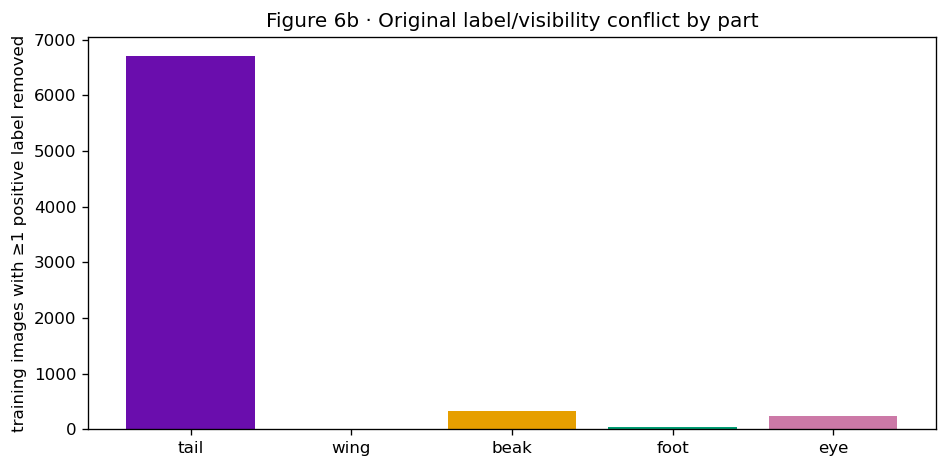

,changed_positive_labels,images_with_change
tail,6711,6711
wing,12,12
beak,334,334
foot,42,42
eye,247,247


In [8]:
# ALT: FunnyBird training-image counts whose positive part-concept labels change under the matched visibility-aware relabeling rule.
import pickle
std_path=CURATED/"funnybirds_processed_trainval"/"train.pkl"
rl_path=CURATED/"funnybirds_processed_rl_trainval"/"train.pkl"
if not (std_path.exists() and rl_path.exists()):
    print("INCOMPLETE: matched standard/RLv2 training records are not both present")
else:
    std=pickle.loads(std_path.read_bytes()); rl=pickle.loads(rl_path.read_bytes())
    if len(std)!=len(rl): raise RuntimeError("standard/RLv2 train lengths differ")
    changes={p:0 for p in ORDER}; image_changes={p:0 for p in ORDER}
    for a,b in zip(std,rl):
        for key in a:
            if key=="attribute_label": continue
            av,bv=a[key],b[key]
            equal=np.array_equal(np.asarray(av),np.asarray(bv)) if isinstance(av,(list,tuple,np.ndarray)) else av==bv
            if not bool(equal): raise RuntimeError(f"non-label record field differs: {key}")
        ca=np.asarray(a["attribute_label"]); cb=np.asarray(b["attribute_label"])
        for p,(lo,hi) in SPANS.items():
            n=int(((ca[lo:hi]==1)&(cb[lo:hi]==0)).sum()); changes[p]+=n; image_changes[p]+=int(n>0)
    CONFLICT=pd.DataFrame({"changed_positive_labels":changes,"images_with_change":image_changes}).reindex(ORDER)
    fig,ax=plt.subplots(figsize=(8,4)); ax.bar(CONFLICT.index,CONFLICT.images_with_change,color=[COLORS[p] for p in CONFLICT.index])
    ax.set_ylabel("training images with ≥1 positive label removed")
    ax.set_title("Figure 6b · Original label/visibility conflict by part")
    plt.tight_layout(); plt.show(); display(CONFLICT)


### Review record for Figure 6b

- **Literal observation:** Visibility-aware preprocessing removes 6,711 positive tail labels, compared with 334 beak, 247 eye, 42 foot, and 12 wing labels; every change occurs on a distinct training image.
- **Strongest alternative explanation:** These are training-signal counts, not measured causal effects on the trained standard model.
- **Discriminating test:** Compare otherwise matched standard and RLv2 checkpoints on the same fixed renders.
- **Limited conclusion:** `ACCEPTED FOR a measured label/visibility conflict, especially for tail; causal credit remains deferred to notebook 03rl.`
- **Next question:** Are some exact visual variants much harder than others?


## 7 · Do exact source and donor values explain the failures?

**Question.** Do exact source and donor values explain the failures?

**Variables and prediction.** For every part, compare the inserted donor value with the concept value that has the largest post-swap raw score. A clean diagonal means exact visual values are distinguished; recurring bright columns indicate default answers.

**Method.** Display all parts and all values with row-normalized counts.

### Figure 7 · Do exact source and donor values explain the failures?

**How to read the figure.** Each heatmap row is the value actually inserted and each column is the value
with the largest post-swap raw logit. A bright diagonal means the model names
the inserted value; bright off-diagonal cells show systematic confusion.
Every FunnyBird part and every value is included.


/tmp/tmp.kyRdsMu6aN/ipykernel_3038585/1806519715.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show(); display(pd.Series(diag,name="diagonal_rate").to_frame().round(3))


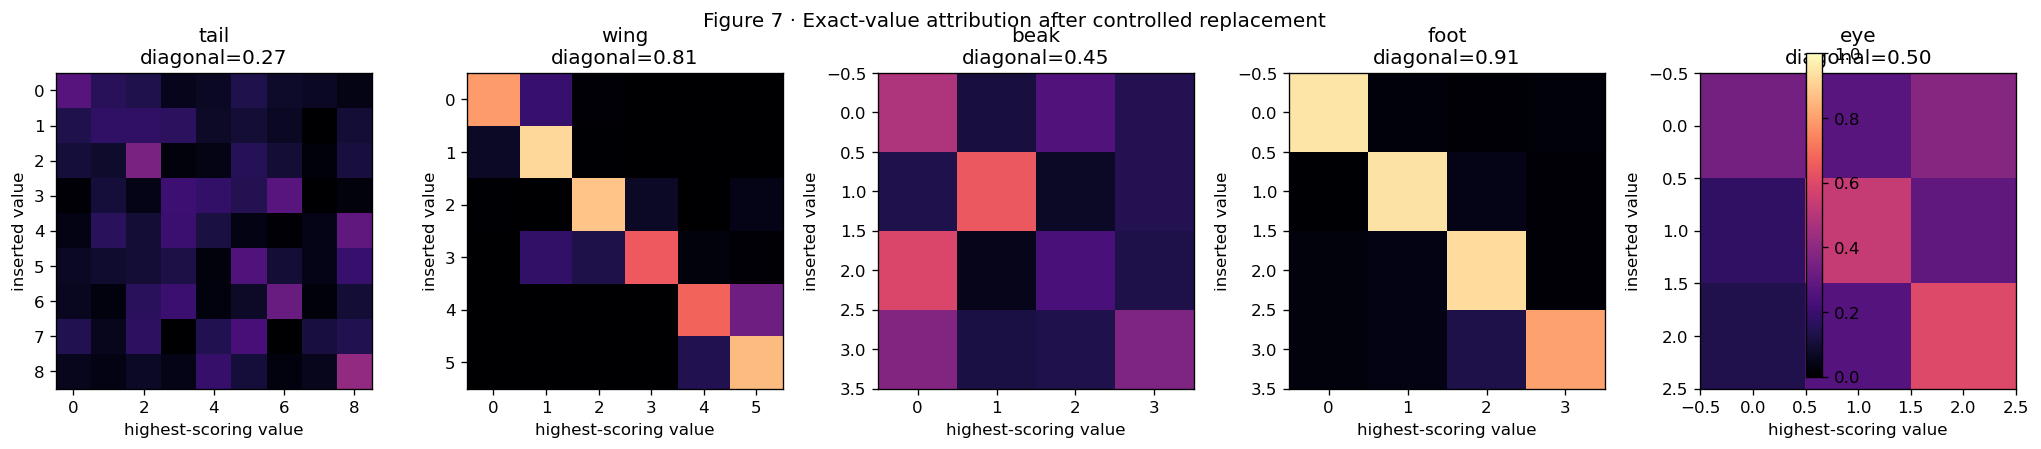

,diagonal_rate
tail,0.272
wing,0.807
beak,0.448
foot,0.905
eye,0.501


In [9]:
# ALT: Five row-normalized confusion matrices comparing inserted and highest-scoring FunnyBird part values.
available=[p for p in ORDER if any(c.startswith(f"z_cf_{p}_") for c in S.columns)]
if set(available)!=set(ORDER): raise RuntimeError(f"missing all-part post-swap concept logits: have {available}")
fig,axes=plt.subplots(1,5,figsize=(17,3.5))
diag={}
for ax,p in zip(axes,ORDER):
    cols=sorted([c for c in S if c.startswith(f"z_cf_{p}_")],key=lambda x:int(x.rsplit("_",1)[1]))
    d=S[S.part==p].dropna(subset=cols); donor=d.var_donor.astype(int).to_numpy(); pred=d[cols].to_numpy().argmax(1)
    M=np.zeros((len(cols),len(cols)))
    for a,b in zip(donor,pred):
        if 0<=a<len(cols): M[a,b]+=1
    M=M/np.maximum(M.sum(1,keepdims=True),1); diag[p]=(donor==pred).mean()
    im=ax.imshow(M,vmin=0,vmax=1,cmap="magma"); ax.set_title(f"{p}\ndiagonal={diag[p]:.2f}")
    ax.set_xlabel("highest-scoring value"); ax.set_ylabel("inserted value")
fig.colorbar(im,ax=axes,fraction=.015); fig.suptitle("Figure 7 · Exact-value attribution after controlled replacement")
plt.tight_layout(); plt.show(); display(pd.Series(diag,name="diagonal_rate").to_frame().round(3))


### Review record for Figure 7

- **Literal observation:** Post-swap donor-value recognition is graded: diagonal rates are tail 0.272, wing 0.807, beak 0.448, foot 0.905, and eye 0.501. Tail is weakest and foot strongest, rather than all parts failing equally.
- **Strongest alternative explanation:** Different parts have different numbers and frequencies of variants, so raw diagonal rates are not directly interchangeable.
- **Discriminating test:** Relate each donor value to species support and its part's alternative count.
- **Limited conclusion:** `ACCEPTED FOR exact-value difficulty as an additional graded contributor.`
- **Next question:** Do rarity or a larger choice set organize those value-level failures?


## 7b · Are difficult values simply rare or drawn from a larger alternative set?

**Question.** Are difficult values simply rare or drawn from a larger alternative set?

**Variables and prediction.** For every donor value, compare its source-species support with the rate where `response_delta>0` but the final margin remains negative; also report the total number of alternatives for its part. An association supports frequency or choice-set difficulty, but five part-level counts cannot establish a stable correlation.

**Method.** Label every exact value and show its number of swap rows.

### Figure 7b · Are difficult values simply rare or drawn from a larger alternative set?

**How to read the figure.** Each labelled point is one donor value. The x-axis is how many species support
that value; the y-axis is the fraction of its swaps that responded donorward
but still ended source-negative. A consistent downward or upward pattern
would support frequency as an organizer. The number of alternatives is
reported but cannot be cleanly separated with only five parts.


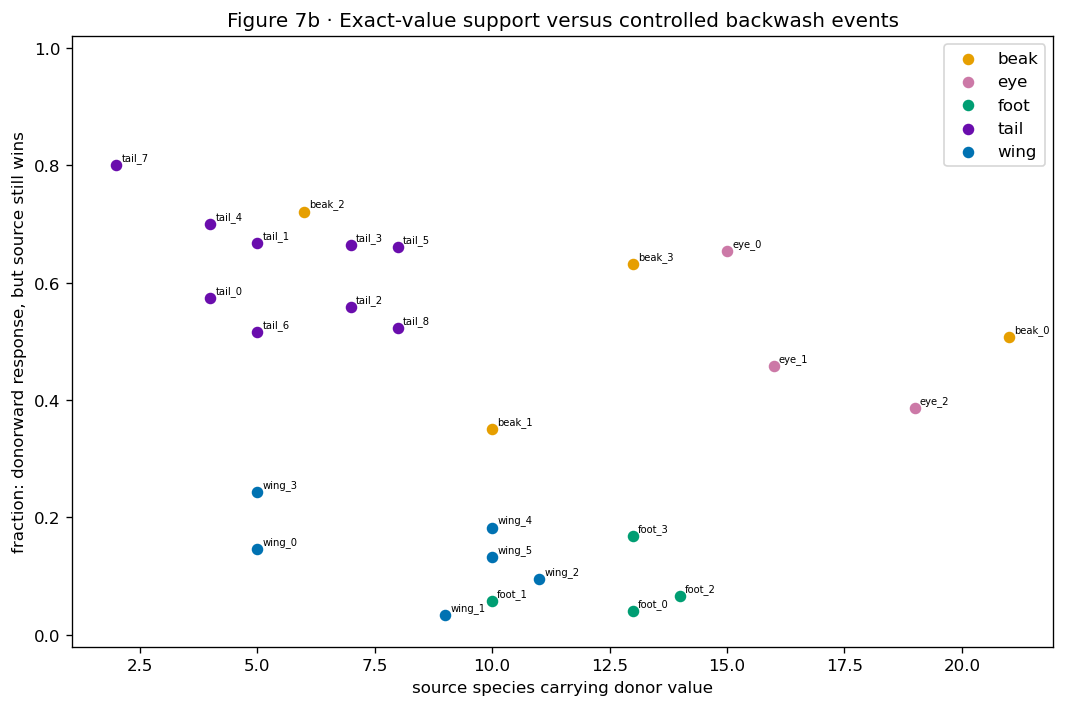

,part,var_donor,n_rows,species_support,responded_but_source_wins_rate,median_margin,alternatives_in_part
0,beak,0,345,21,0.507,-0.184,4
1,beak,1,245,10,0.351,5.762,4
2,beak,2,190,6,0.721,-9.584,4
3,beak,3,220,13,0.632,-2.775,4
4,eye,0,300,15,0.653,-2.221,3
5,eye,1,345,16,0.458,0.768,3
6,eye,2,355,19,0.386,5.313,3
7,foot,0,220,13,0.041,14.182,4
8,foot,1,240,10,0.058,18.227,4
9,foot,2,290,14,0.066,13.964,4


In [10]:
# ALT: Labelled FunnyBird donor-value plot of species support versus the rate where donor pixels move the margin but the old source remains larger.
VS=(S.groupby(["part","var_donor"]).agg(n_rows=("margin","size"),species_support=("sid_donor","nunique"),
     responded_but_source_wins_rate=("responded_but_source_wins","mean"),median_margin=("margin","median")).reset_index())
VS["alternatives_in_part"]=VS.part.map({p:hi-lo for p,(lo,hi) in SPANS.items()})
fig,ax=plt.subplots(figsize=(9,6))
for p,d in VS.groupby("part"):
    ax.scatter(d.species_support,d.responded_but_source_wins_rate,s=35,color=COLORS[p],label=p)
    for r in d.itertuples(): ax.annotate(f"{p}_{int(r.var_donor)}",(r.species_support,r.responded_but_source_wins_rate),fontsize=6,xytext=(3,3),textcoords="offset points")
ax.set_xlabel("source species carrying donor value"); ax.set_ylabel("fraction: donorward response, but source still wins")
ax.set_ylim(-.02,1.02); ax.legend(); ax.set_title("Figure 7b · Exact-value support versus controlled backwash events")
plt.tight_layout(); plt.show(); display(VS.round(3))


### Review record for Figure 7b

- **Literal observation:** Within each part, source-species support does not show a consistent monotone relationship with the event rate. Tail variants remain high and wing/foot variants low across overlapping support values.
- **Strongest alternative explanation:** The number of alternatives is constant within a part and therefore remains confounded with all other part-level differences.
- **Discriminating test:** Use more independent part families or a design that changes choice-set size while holding pixels and species fixed.
- **Limited conclusion:** `VALID TEST, NO CLEAR SUPPORT that frequency or alternative count alone explains the part ordering.`
- **Next question:** Does unchanged source species organize what remains after exact values?


## 8 · Does source species organize the remaining error after exact values?

**Question.** Does source species organize the remaining error after exact values?

**Variables and prediction.** Subtract the mean margin for each `(part, source value, donor value)` combination, then summarize the residual by source species. Persistent species differences support an additional unchanged-body/species association, but remain observational.

**Method.** Show every part and require at least five rows per displayed species estimate.

### Figure 8 · Does source species organize the remaining error after exact values?

**How to read the figure.** First remove the average margin for the same part, source value, and donor
value. Each remaining point is a source-species mean residual. Zero means that
species behaves like the matched-value average; positive or negative values
mean it systematically shifts the final margin. This is association with the
unchanged bird context, not an independent species manipulation.


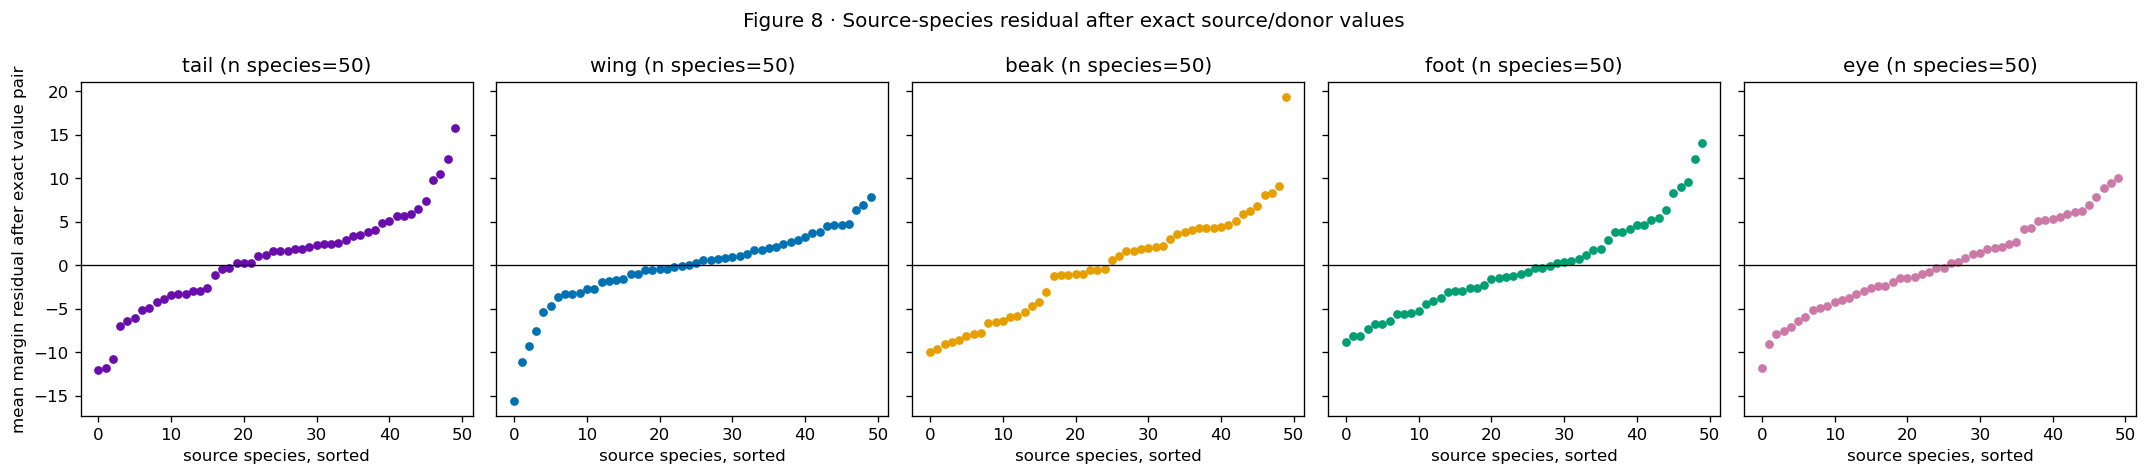

,min,median,max,std,count
part,,,,,
beak,-9.920,0.104,19.318,6.069,50
eye,-11.748,-0.307,10.037,5.154,50
foot,-8.766,-0.921,14.001,5.367,50
tail,-11.978,1.588,15.767,5.699,50
wing,-15.536,0.152,7.865,4.396,50


In [11]:
# ALT: Per-source-species FunnyBird margin residuals after controlling exact source and donor values, shown for all parts.
R=S.copy(); R["value_pair_mean"]=R.groupby(["part","var_src","var_donor"]).margin.transform("mean")
R["margin_after_value_pair"]=R.margin-R.value_pair_mean
SP=(R.groupby(["part","sid_src"]).agg(n=("margin","size"),residual=("margin_after_value_pair","mean"))
      .reset_index().query("n>=5"))
fig,axes=plt.subplots(1,5,figsize=(18,4),sharey=True)
for ax,p in zip(axes,ORDER):
    d=SP[SP.part==p].sort_values("residual")
    ax.scatter(np.arange(len(d)),d.residual,color=COLORS[p],s=18)
    ax.axhline(0,color="black",lw=.8); ax.set_title(f"{p} (n species={len(d)})")
    ax.set_xlabel("source species, sorted")
axes[0].set_ylabel("mean margin residual after exact value pair")
fig.suptitle("Figure 8 · Source-species residual after exact source/donor values")
plt.tight_layout(); plt.show(); display(SP.groupby("part").residual.agg(["min","median","max","std","count"]).round(3))


### Review record for Figure 8

- **Literal observation:** After centering each part/source-value/donor-value combination, mean residuals still span roughly 20-35 raw-z units across the 50 source species in every part.
- **Strongest alternative explanation:** The descriptive species means can also absorb pose or repeated-row composition, and they are not a causal body manipulation.
- **Discriminating test:** Check whether species is recoverable from held-out concept vectors and whether species improves held-out margin prediction.
- **Limited conclusion:** `ACCEPTED FOR an observational source-species association beyond exact values.`
- **Next question:** Is species information actually present in the learned concept representation?


## 8b · How much species identity is recoverable from the learned concept vector?

**Question.** How much species identity is recoverable from the learned concept vector?

**Variables and prediction.** Train a held-out linear species probe on the full raw-logit vector and on each part block separately. Accuracy above the 1/50 chance level shows stored species information; it does not identify the pixels responsible or prove backward causal flow.

**Method.** Use one fixed stratified 70/30 split of the held-out prediction population.

### Figure 8b · How much species identity is recoverable from the learned concept vector?

**How to read the figure.** The y-axis is held-out species-classification accuracy from raw concept logits.
The dashed reference is 1/50 chance. `all` uses all concept outputs; each part
bar uses only that part's outputs. Above-chance decoding shows species
information is available in the representation, not that it caused backwash.


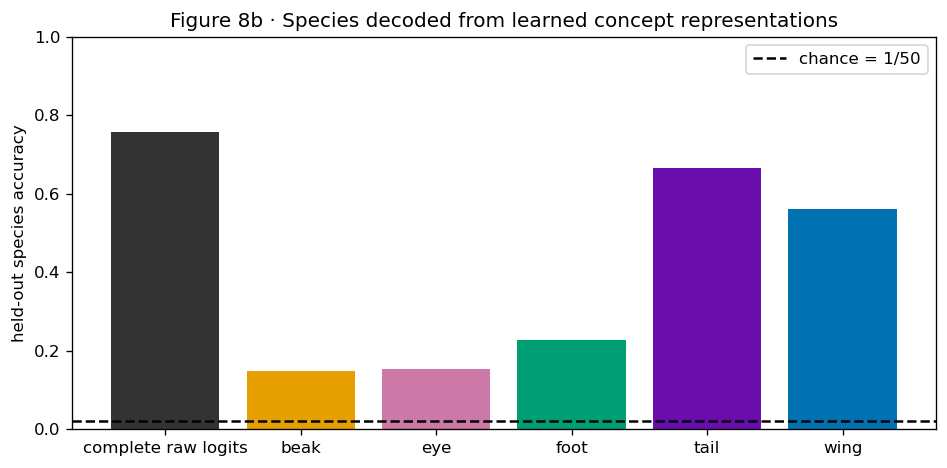

,block,species_accuracy,dimensions
0,complete raw logits,0.758,26
1,beak,0.149,4
2,eye,0.153,3
3,foot,0.229,4
4,tail,0.667,9
5,wing,0.563,6


In [12]:
# ALT: Held-out FunnyBird species-decoding accuracy from the complete raw concept vector and each individual part block.
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
y_saved=np.asarray(saved["y"]).reshape(-1).astype(int)
idx=np.arange(len(y_saved)); tr,te=train_test_split(idx,test_size=.30,random_state=20260803,stratify=y_saved)
blocks={"complete raw logits":np.arange(z_saved.shape[1])}
blocks.update({p:np.arange(lo,hi) for p,(lo,hi) in SPANS.items()})
probe=[]
for name,cols in blocks.items():
    model=make_pipeline(StandardScaler(),LogisticRegression(max_iter=3000,C=1.0,random_state=20260803))
    model.fit(z_saved[tr][:,cols],y_saved[tr]); probe.append({"block":name,"species_accuracy":accuracy_score(y_saved[te],model.predict(z_saved[te][:,cols])),"dimensions":len(cols)})
PROBE=pd.DataFrame(probe)
fig,ax=plt.subplots(figsize=(8,4)); ax.bar(PROBE.block,PROBE.species_accuracy,color=["#333333"]+[COLORS.get(x,"#999999") for x in PROBE.block.iloc[1:]])
ax.axhline(1/len(np.unique(y_saved)),color="black",ls="--",label="chance = 1/50")
ax.set_ylim(0,1); ax.set_ylabel("held-out species accuracy"); ax.set_title("Figure 8b · Species decoded from learned concept representations")
ax.legend(); plt.tight_layout(); plt.show(); display(PROBE.round(3))


### Review record for Figure 8b

- **Literal observation:** Species accuracy is 0.758 from all raw logits versus 0.02 chance; tail alone reaches 0.667 and wing 0.563, with every part block above chance.
- **Strongest alternative explanation:** FunnyBird concepts help define species, so decodability shows available species information but not that species caused a particular concept error.
- **Discriminating test:** Ask whether adding source species improves held-out prediction of final margin.
- **Limited conclusion:** `ACCEPTED FOR substantial species information in the learned concept vector.`
- **Next question:** How much of the swap margin generalizes from the proposed explanatory blocks?


## 9 · How much does each observed block account for?

**Question.** How much does each observed block account for?

**Variables and prediction.** Predict the raw final margin on held-out render IDs using progressively richer categorical blocks. Lower held-out error means the added block organizes the outcome; remaining error is the measured residual.

**Method.** Use stable five-fold image-level splits, training-fold group means with shrinkage, and no RLv2 variables.

### Figure 9 · How much does each observed block account for?

**How to read the figure.** The y-axis is held-out RMSE when predicting final raw-logit margin; lower is
better. Starting from part alone, blocks are added in order: visibility,
exact source/donor values and support, then source species. A decrease means
the new block predicts unseen render IDs better. The final nonzero error is
the unexplained residual; an increase is negative evidence for that model.


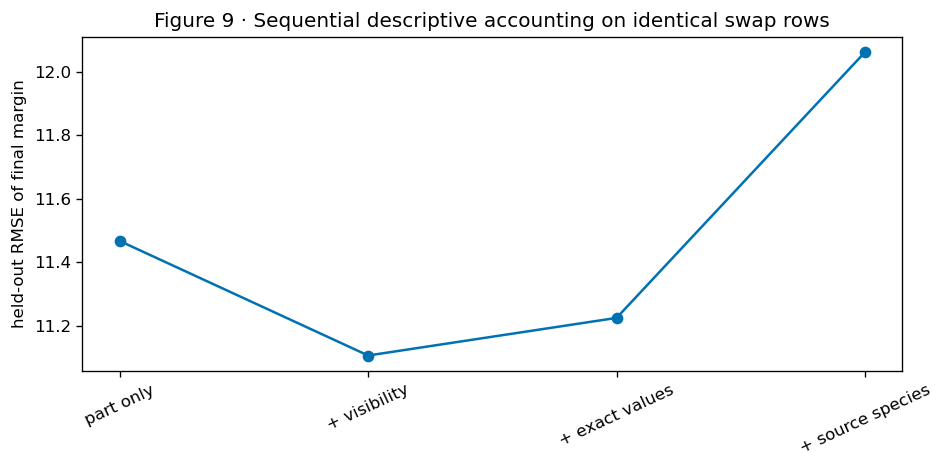

,stage,rmse,mae
0,part only,11.467,9.182
1,+ visibility,11.106,8.854
2,+ exact values,11.225,8.999
3,+ source species,12.062,9.773


In [13]:
# ALT: Held-out final-margin prediction error after adding FunnyBird visibility, exact values, and source species sequentially.
import hashlib
A=S.copy(); A["vis_bin"]=pd.cut(A.pixel_count_cf,[-1,19,49,99,199,499,np.inf],labels=False)
unit=(A["render_id"].astype(str) if "render_id" in A else
      A.get("li",pd.Series(np.arange(len(A)),index=A.index)).astype(str))
A["fold"]=unit.map(lambda x:int(hashlib.sha1(x.encode()).hexdigest(),16)%5)
stages=[("part only",["part"]),("+ visibility",["part","vis_bin"]),
        ("+ exact values",["part","vis_bin","var_src","var_donor"]),
        ("+ source species",["part","vis_bin","var_src","var_donor","sid_src"])]
rows=[]
for stage,cols in stages:
    pred=pd.Series(index=A.index,dtype=float)
    for fold in range(5):
        tr=A[A.fold!=fold]; te=A[A.fold==fold]
        prior=tr.margin.mean(); stats=tr.groupby(cols).margin.agg(["mean","count"]).reset_index()
        stats["estimate"]=(stats["mean"]*stats["count"]+prior*10)/(stats["count"]+10)
        joined=te[cols].merge(stats[cols+["estimate"]],on=cols,how="left")
        pred.loc[te.index]=joined.estimate.fillna(prior).to_numpy()
    rows.append({"stage":stage,"rmse":float(np.sqrt(np.mean((A.margin-pred)**2))),
                 "mae":float(np.mean(np.abs(A.margin-pred)))})
ACCOUNT=pd.DataFrame(rows)
fig,ax=plt.subplots(figsize=(8,4)); ax.plot(ACCOUNT.stage,ACCOUNT.rmse,"o-",color="#0072B2")
ax.set_ylabel("held-out RMSE of final margin"); ax.tick_params(axis="x",rotation=25)
ax.set_title("Figure 9 · Sequential descriptive accounting on identical swap rows")
plt.tight_layout(); plt.show(); display(ACCOUNT.round(3))


### Review record for Figure 9

- **Literal observation:** Held-out RMSE improves only from 11.467 to 11.106 when visibility is added. It then worsens to 11.225 with exact values and 12.062 with source species.
- **Strongest alternative explanation:** High-cardinality categorical means may be too sparse or poorly regularized, but that possibility cannot be counted as positive evidence.
- **Discriminating test:** Use seed replication or a preregistered hierarchical/regularized predictor before assigning generalizing explanatory credit to exact values or species.
- **Limited conclusion:** `VALID TEST, NO SUPPORT from this predictor that exact values or source species account for held-out margin variance; only visibility gives a small improvement.`
- **Next question:** Does the concept-layer margin have a large downstream class consequence?


## 10 · Does the concept-layer error materially alter species prediction?

**Question.** Does the concept-layer error materially alter species prediction?

**Variables and prediction.** Relate final concept margin to the model's donor-species probability, which is a different downstream quantity. A small downstream change would limit the harm to explanation reliability rather than widespread class failure.

**Method.** Use independent final-margin bins and print bin counts.

### Figure 10 · Does the concept-layer error materially alter species prediction?

**How to read the figure.** Swaps are divided into independent bins by final donor-minus-source concept
margin on the x-axis. The y-axis is the model's mean probability for the donor
species, with the number of rows printed per bin. This asks whether concept
grounding failure has a downstream class effect; it is intentionally the one
place where class probability, rather than raw concept `z`, is the outcome.


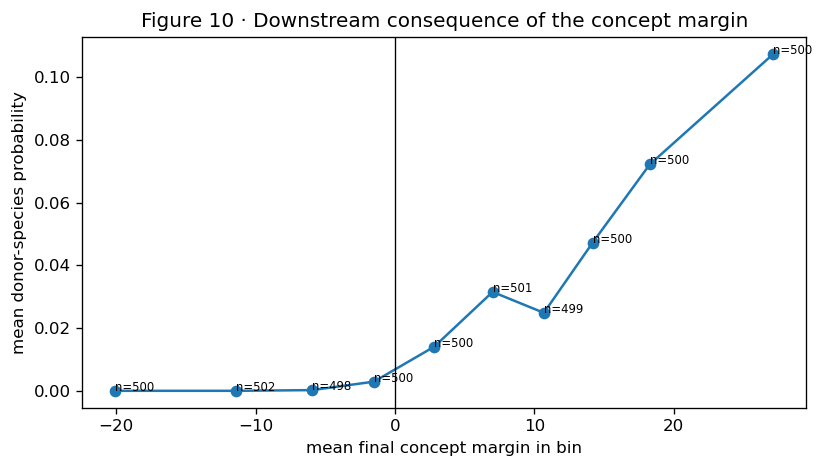

,margin_bin,n,mean_margin,mean_donor_species_prob
0,"(-45.455, -14.551]",500,-20.066,0.000
1,"(-14.551, -8.525]",502,-11.400,0.000
2,"(-8.525, -3.337]",498,-5.967,0.000
3,"(-3.337, 0.312]",500,-1.506,0.003
4,"(0.312, 5.076]",500,2.818,0.014
5,"(5.076, 8.821]",501,7.007,0.032
6,"(8.821, 12.461]",499,10.686,0.025
7,"(12.461, 16.049]",500,14.184,0.047
8,"(16.049, 20.953]",500,18.285,0.072
9,"(20.953, 57.093]",500,27.160,0.107


In [14]:
# ALT: Binned relationship between FunnyBird final concept margin and downstream donor-species probability.
prob_col=next((c for c in ["p_cf_donor","p_donor_cf","donor_species_prob"] if c in S),None)
if prob_col is None:
    print("INCOMPLETE: swap CSV has no donor-species probability column")
else:
    D=S.copy(); D["margin_bin"]=pd.qcut(D.margin,10,duplicates="drop")
    Q=D.groupby("margin_bin",observed=True).agg(n=(prob_col,"size"),mean_margin=("margin","mean"),mean_donor_species_prob=(prob_col,"mean")).reset_index()
    fig,ax=plt.subplots(figsize=(7,4)); ax.plot(Q.mean_margin,Q.mean_donor_species_prob,"o-")
    for r in Q.itertuples(): ax.annotate(f"n={r.n}",(r.mean_margin,r.mean_donor_species_prob),fontsize=7)
    ax.axvline(0,color="black",lw=.8); ax.set_xlabel("mean final concept margin in bin")
    ax.set_ylabel("mean donor-species probability"); ax.set_title("Figure 10 · Downstream consequence of the concept margin")
    plt.tight_layout(); plt.show(); display(Q.round(3))


### Review record for Figure 10

- **Literal observation:** Mean donor-species probability rises from approximately zero at negative margins to 0.107 in the most donor-positive bin, with about 500 rows per bin.
- **Strongest alternative explanation:** A one-part replacement need not make the whole donor species plausible because the unchanged body and other parts still belong to the source.
- **Discriminating test:** Replicate across seeds and compare class-logit changes, not only final probability.
- **Limited conclusion:** `ACCEPTED FOR a monotone but modest single-swap downstream donor-species effect; the primary harm here is explanation fidelity.`
- **Next question:** Does minimality change the accepted standard-CBM quantities?


## 11 · Standard-CBM evidence ledger

Figures 1–10 were displayed and reviewed together on 2026-08-04.

| Predicate or explanation | Direct measurement | Status after review |
|---|---|---|
| model outputs are usable | Figure 1 | `ACCEPTED FOR seed-1 model health` |
| interventions are valid | Figure 2 | `ACCEPTED FOR validated fixed renders` |
| inserted pixels cause donorward movement | Figure 3 | `ACCEPTED FOR all five parts` |
| old source can remain stronger after that movement | Figure 4 | `ACCEPTED; strongest for tail, beak, eye` |
| direction artifact excluded | Figure 5 | `ACCEPTED` |
| visibility contribution | Figure 6 | `ACCEPTED AS CONTRIBUTOR, NOT SUFFICIENT` |
| training label/mask conflict measured | Figure 6b | `MEASURED; causal effect deferred to RLv2` |
| exact-value contribution | Figure 7 | `ACCEPTED AS GRADED CONTRIBUTOR` |
| frequency/alternative-count explanation | Figure 7b | `VALID TEST, NO CLEAR SUPPORT AS SOLE EXPLANATION` |
| source-species residual | Figure 8 | `OBSERVATIONAL ASSOCIATION` |
| species information in learned representation | Figure 8b | `ACCEPTED FOR AVAILABILITY` |
| sequential descriptive accounting | Figure 9 | `VISIBILITY IMPROVES; EXACT VALUES/SPECIES DO NOT` |
| downstream class consequence | Figure 10 | `MONOTONE BUT MODEST DONOR-PROBABILITY EFFECT` |

**Next report question.** Notebook 03 asks whether the MCBM minimality
penalty changes these same accepted quantities. It must not replace the
standard-CBM result established here.


# Methods appendix · measurements not used in the main claim

The reciprocal mask-deletion and randomized-patch experiments are retained
as method-development history. They did not reproduce the clean FunnyBird
control sufficiently to transfer their causal interpretation to CUB.

- reciprocal mask deletion: `METHOD NOT CALIBRATED FOR CROSS-DATASET CAUSAL COMPARISON`;
- randomized patch V1/V2: local pixel response was measurable in selected
  examples, but the all-part control was not calibrated and wing coverage was
  inadequate;
- none of these outcomes invalidates the validated renderer swap above.

Full artifacts and scripts remain under `analysis/paired_mask_deletion.py`,
`analysis/randomized_patch_masking.py`, and their output directories. They
are not rerun by this notebook.


# Provenance appendix

Record after execution: Git commit, checkpoint path, prediction path, swap
CSV path, fixed-render audit path, row counts, seeds, and exclusions. A
stale HTML is not synchronized evidence.
